# 07 补充实验：Amount 换一种缩放方法，结果会变吗

02 里 Amount 用的是稳健缩放（减中位数、除以四分位距）。这是一个"可以换"的选择，这里把常见的几种都试一遍，看对结果影响多大：

| 方案 | 做法 |
|---|---|
| 不缩放 | Amount 保持原始金额（0 ~ 2.5 万） |
| 标准化 | 减均值、除以标准差 |
| 稳健缩放（02 用的） | 减中位数、除以四分位距 |
| 取对数再标准化 | 先算 log(1 + 金额)，再标准化。Kaggle 上很多人这么做 |

Time 保持标准化不变，V1~V28 不动，只改 Amount 一列。
只测对缩放敏感的三个模型：逻辑回归、SVM、MLP。树模型（随机森林、XGBoost）只看"大于还是小于某个数"，单调的缩放不会改变它们的结果，所以不用测。
切分和 05、06 完全一样，挑选看验证集，测试集仅作参考。

In [1]:
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

if os.path.exists('/content'):
    os.system('apt-get -qq install -y fonts-noto-cjk > /dev/null')
    font_path = glob.glob('/usr/share/fonts/**/NotoSansCJK*-Regular.ttc', recursive=True)[0]
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
else:
    plt.rcParams['font.family'] = ['PingFang SC', 'Heiti SC', 'Arial Unicode MS', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
import time
import warnings
import numpy as np
import pandas as pd
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import average_precision_score
warnings.filterwarnings('ignore', category=ConvergenceWarning)

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/data-mining'
except ImportError:
    DATA_DIR = os.environ.get('CCFD_DATA_DIR', 'data')

train_df = pd.read_csv(f'{DATA_DIR}/train_scaled.csv')
test_df = pd.read_csv(f'{DATA_DIR}/test_scaled.csv')
train_amount = pd.read_csv(f'{DATA_DIR}/train_amount_raw.csv')['Amount'].values
test_amount = pd.read_csv(f'{DATA_DIR}/test_amount_raw.csv')['Amount'].values
feature_cols = [c for c in train_df.columns if c != 'Class']
amount_col = feature_cols.index('Amount')

row_id = pd.util.hash_pandas_object(train_df, index=False).values
uniq = pd.DataFrame({'row_id': row_id, 'Class': train_df['Class'].values}).drop_duplicates('row_id')
fit_ids, _ = train_test_split(uniq['row_id'], test_size=0.2, stratify=uniq['Class'], random_state=42)
is_fit = np.isin(row_id, fit_ids.values)

X_all, y_all = train_df[feature_cols].values, train_df['Class'].values
X_test_base, y_test = test_df[feature_cols].values, test_df['Class'].values
y_fit, y_val = y_all[is_fit], y_all[~is_fit]
amt_fit, amt_val = train_amount[is_fit], train_amount[~is_fit]
print(f'拟合用 {is_fit.sum()} 行，验证集 {(~is_fit).sum()} 行，测试集 {len(y_test)} 行')

拟合用 159509 行，验证集 39882 行，测试集 85416 行


## 1. 四种缩放方法下的 Amount

缩放规则只用"拟合用"的那部分训练数据来算，再套用到验证集和测试集。

In [3]:
def scaled_amount(method):
    a_fit, a_val, a_test = amt_fit.reshape(-1, 1), amt_val.reshape(-1, 1), test_amount.reshape(-1, 1)
    if method == '不缩放':
        return a_fit, a_val, a_test
    if method == '取对数再标准化':
        a_fit, a_val, a_test = np.log1p(a_fit), np.log1p(a_val), np.log1p(a_test)
        scaler = StandardScaler().fit(a_fit)
    elif method == '标准化':
        scaler = StandardScaler().fit(a_fit)
    else:
        scaler = RobustScaler().fit(a_fit)
    return scaler.transform(a_fit), scaler.transform(a_val), scaler.transform(a_test)

def build(method):
    a_fit, a_val, a_test = scaled_amount(method)
    X_fit, X_val, X_test = X_all[is_fit].copy(), X_all[~is_fit].copy(), X_test_base.copy()
    X_fit[:, amount_col], X_val[:, amount_col], X_test[:, amount_col] = a_fit[:, 0], a_val[:, 0], a_test[:, 0]
    return X_fit, X_val, X_test

methods = ['不缩放', '标准化', '稳健缩放（02 用的）', '取对数再标准化']
for m in methods:
    X_fit, _, _ = build(m)
    col = X_fit[:, amount_col]
    print(f'{m:<12} 缩放后 Amount：中位数 {np.median(col):10.2f}，最大值 {col.max():10.2f}')

不缩放          缩放后 Amount：中位数      22.04，最大值   18910.00
标准化          缩放后 Amount：中位数      -0.27，最大值      77.62
稳健缩放（02 用的）  缩放后 Amount：中位数       0.00，最大值     262.66
取对数再标准化      缩放后 Amount：中位数      -0.01，最大值       4.04


## 2. 三个模型在四种缩放下的成绩

- 逻辑回归：加类别权重（和 02 一样）
- SVM：用 06 调出来的最优参数（从 `svm_best.json` 读取），训练用全部欺诈 + 2 万正常样本；另加一行 gamma=scale 的 SVM，用来演示下面说的"假象"
- MLP：30 → 64 → 32 → 1，训练 20 轮（和 04、05 一样）

大约要 1~3 分钟。

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

rng = np.random.default_rng(42)
svm_rows = np.concatenate([np.flatnonzero(y_fit == 1),
                           rng.choice(np.flatnonzero(y_fit == 0), 20000, replace=False)])

import json
with open(f'{DATA_DIR}/svm_best.json') as f:
    best = json.load(f)
print('06 选出的 SVM 参数：', best)

rows = []
for m in methods:
    X_fit, X_val, X_test = build(m)
    models = {
        '逻辑回归': lambda: LogisticRegression(class_weight='balanced', max_iter=1000).fit(X_fit, y_fit),
        'SVM（调参后）': lambda: SVC(kernel='rbf', C=best['C'], gamma=best['gamma'], class_weight='balanced',
                                 random_state=42).fit(X_fit[svm_rows], y_fit[svm_rows]),
        'SVM（gamma=scale）': lambda: SVC(kernel='rbf', C=best['C'], gamma='scale', class_weight='balanced',
                                       random_state=42).fit(X_fit[svm_rows], y_fit[svm_rows]),
        'MLP': lambda: MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=20, random_state=42).fit(X_fit, y_fit),
    }
    for name, make in models.items():
        start = time.time()
        model = make()
        score = (lambda X: model.decision_function(X)) if name.startswith('SVM') else (lambda X: model.predict_proba(X)[:, 1])
        rows.append({'缩放方法': m, '模型': name,
                     '验证集 AUPRC': average_precision_score(y_val, score(X_val)),
                     '测试集 AUPRC': average_precision_score(y_test, score(X_test)),
                     '训练耗时(秒)': time.time() - start})

result = pd.DataFrame(rows)
result.to_csv(f'{DATA_DIR}/results_scaling.csv', index=False)
result.pivot(index='缩放方法', columns='模型', values='验证集 AUPRC').loc[methods].round(4)

06 选出的 SVM 参数： {'C': 100.0, 'gamma': 0.0001}


模型,MLP,SVM（gamma=scale）,SVM（调参后）,逻辑回归
缩放方法,,,,
不缩放,0.8469,0.7068,0.7159,0.7160
标准化,0.8411,0.5890,0.7773,0.7356
稳健缩放（02 用的）,0.8463,0.6270,0.7771,0.7159
取对数再标准化,0.8521,0.6254,0.7698,0.7334


上表是**验证集** AUPRC。下表是测试集 AUPRC，仅供参考，不用来做选择。

In [5]:
result.pivot(index='缩放方法', columns='模型', values='测试集 AUPRC').loc[methods].round(4)

模型,MLP,SVM（gamma=scale）,SVM（调参后）,逻辑回归
缩放方法,,,,
不缩放,0.8158,0.6077,0.6060,0.7062
标准化,0.7876,0.4690,0.6826,0.7025
稳健缩放（02 用的）,0.7845,0.5345,0.6774,0.7043
取对数再标准化,0.7967,0.5208,0.6707,0.7104


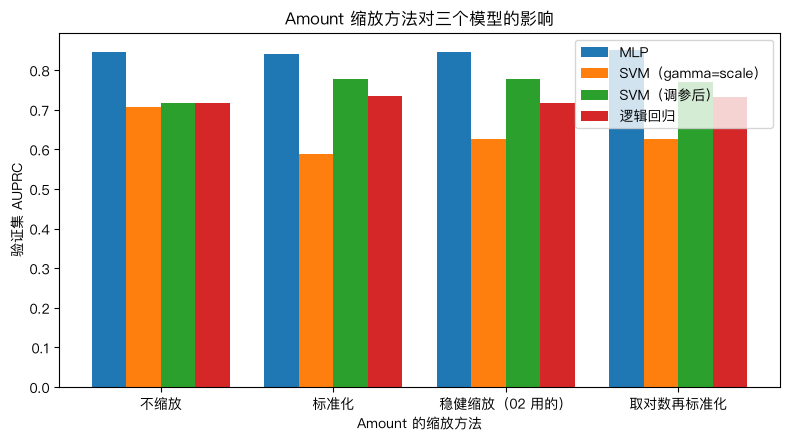

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
pivot = result.pivot(index='缩放方法', columns='模型', values='验证集 AUPRC').loc[methods]
x = np.arange(len(methods))
for i, name in enumerate(pivot.columns):
    ax.bar(x + (i - 1.5) * 0.2, pivot[name], width=0.2, label=name)
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_xlabel('Amount 的缩放方法')
ax.set_ylabel('验证集 AUPRC')
ax.set_title('Amount 缩放方法对三个模型的影响')
ax.legend()
plt.tight_layout()
plt.show()

## 一个假象：为什么"不缩放"时 gamma=scale 的 SVM 反而好

`gamma='scale'` 不是固定值，而是按数据自动算：gamma = 1 ÷（特征数 × 全部数据的方差）。
- Amount 不缩放时，金额的方差非常大，算出来的 gamma 只有约 0.0000125，RBF 核变得非常"宽"，每个样本影响很大一片区域；
- 缩放后，gamma 约为 0.018，核"窄"得多。

所以"不缩放更好"其实是"更小的 gamma 更好"，跟缩放本身无关。06 把 gamma 的搜索范围扩大到 0.0001 之后，缩放后的数据也能达到同样的水平——对比上表"SVM（调参后）"和"SVM（gamma=scale）"两列。
这是本实验的一个过程记录：一个补充实验暴露了前面调参范围的不足。

## 看完之后记下来（用你自己的话）

1. 哪个模型对缩放方法最敏感？哪个几乎不受影响？
2. "不缩放"比其他三种差多少？这说明缩放为什么必要？
3. 稳健缩放、标准化、取对数之间差别大不大？02 选稳健缩放的决定要不要改？
4. 差距和验证集的噪声（只有 69 笔欺诈）比起来，算不算真的差别？